In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
file_path = '/content/drive/My Drive/borg_traces_data.csv'
df = pd.read_csv(file_path)

In [ ]:
df

,Unnamed: 0,time,instance_events_type,collection_id,scheduling_class,collection_type,priority,alloc_collection_id,instance_index,machine_id,...,assigned_memory,page_cache_memory,cycles_per_instruction,memory_accesses_per_instruction,sample_rate,cpu_usage_distribution,tail_cpu_usage_distribution,cluster,event,failed
0,0,0,2,94591244395,3,1,200,0,144,168846390496,...,0.014435,0.000415,NaN,NaN,1.000000,[0.00314331 0.00381088 0.00401306 0.00415039 0...,[0.00535583 0.00541687 0.00548553 0.00554657 0...,7,FAIL,1
1,1,2517305308183,2,260697606809,2,0,360,221495397286,335,85515092,...,0.000000,0.000000,NaN,NaN,1.000000,[1.23977661e-05 1.23977661e-05 1.23977661e-05 ...,[1.23977661e-05 1.23977661e-05 1.23977661e-05 ...,7,FAIL,1
2,2,195684022913,6,276227177776,2,0,103,0,376,169321752432,...,0.010422,0.000235,0.939919,0.001318,1.000000,[0.01344299 0.01809692 0.0201416 0.02246094 0...,[0.02902222 0.02929688 0.0295105 0.0296936 0...,7,SCHEDULE,0
3,3,0,2,10507389885,3,0,200,0,1977,178294817221,...,0.041626,0.000225,1.359102,0.007643,1.000000,[0.03704834 0.04125977 0.04290771 0.04425049 0...,[0.05535889 0.05584717 0.05633545 0.05718994 0...,8,FAIL,1
4,4,1810627494172,3,25911621841,2,0,0,0,3907,231364893292,...,0.000272,0.000010,NaN,NaN,1.000000,[0. 0. 0. 0. 0...,[0.00041485 0.00041485 0.00041485 0.00041485 0...,2,FINISH,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
405889,405889,0,2,299950285958,1,0,117,0,1341,10625460233,...,0.002117,0.000048,0.693324,0.003158,1.000000,[0.00022793 0.00822449 0.00866699 0.01246643 0...,[0.0222168 0.02261353 0.02294922 0.02404785 0...,8,FAIL,1
405890,405890,18279167039,0,330587213089,2,0,360,330587120885,898,68669881389,...,0.000000,0.002468,1.019433,0.001859,1.000000,[0.01028442 0.02087402 0.02432251 0.02661133 0...,[0.05828857 0.05871582 0.05938721 0.06097412 0...,1,ENABLE,0
405891,405891,733307641549,3,13748637767,3,0,200,13748635759,1959,126641993288,...,0.000000,0.000480,0.990970,0.002941,1.000000,[0.00857544 0.01472473 0.01660156 0.01873779 0...,[0.03515625 0.03552246 0.03729248 0.03912354 0...,2,FINISH,0
405892,405892,1984523129238,2,323372663325,1,0,117,0,6452,191941429308,...,0.001562,0.000229,3.023431,0.015743,0.996667,[0.00024414 0.00030136 0.00036907 0.00073719 0...,[0.00904846 0.00907898 0.00909424 0.00912476 0...,8,FAIL,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 405894 entries, 0 to 405893
Data columns (total 34 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   Unnamed: 0                       405894 non-null  int64  
 1   time                             405894 non-null  int64  
 2   instance_events_type             405894 non-null  int64  
 3   collection_id                    405894 non-null  int64  
 4   scheduling_class                 405894 non-null  int64  
 5   collection_type                  405894 non-null  int64  
 6   priority                         405894 non-null  int64  
 7   alloc_collection_id              405894 non-null  int64  
 8   instance_index                   405894 non-null  int64  
 9   machine_id                       405894 non-null  int64  
 10  resource_request                 405120 non-null  object 
 11  constraint                       405894 non-null  object 
 12  co

# Data Preprocessing

In [ ]:
null_values = df.isnull().sum()
null_values

,0
Unnamed: 0,0
time,0
instance_events_type,0
collection_id,0
scheduling_class,0
collection_type,0
priority,0
alloc_collection_id,0
instance_index,0
machine_id,0


removing unnecessary columns

In [ ]:
df = df.drop(['Unnamed: 0'], axis=1)

checking why the cycles per instructions and memory accesses per instruction is null

In [ ]:
null_rows = df[df['cycles_per_instruction'].isnull() & df['memory_accesses_per_instruction'].isnull()]
null_rows

,time,instance_events_type,collection_id,scheduling_class,collection_type,priority,alloc_collection_id,instance_index,machine_id,resource_request,...,assigned_memory,page_cache_memory,cycles_per_instruction,memory_accesses_per_instruction,sample_rate,cpu_usage_distribution,tail_cpu_usage_distribution,cluster,event,failed
0,0,2,94591244395,3,1,200,0,144,168846390496,"{'cpus': 0.020660400390625, 'memory': 0.014434...",...,0.014435,0.000415,NaN,NaN,1.0,[0.00314331 0.00381088 0.00401306 0.00415039 0...,[0.00535583 0.00541687 0.00548553 0.00554657 0...,7,FAIL,1
1,2517305308183,2,260697606809,2,0,360,221495397286,335,85515092,"{'cpus': 0.00724029541015625, 'memory': 0.0013...",...,0.000000,0.000000,NaN,NaN,1.0,[1.23977661e-05 1.23977661e-05 1.23977661e-05 ...,[1.23977661e-05 1.23977661e-05 1.23977661e-05 ...,7,FAIL,1
4,1810627494172,3,25911621841,2,0,0,0,3907,231364893292,"{'cpus': 0.00244903564453125, 'memory': 0.0002...",...,0.000272,0.000010,NaN,NaN,1.0,[0. 0. 0. 0. 0...,[0.00041485 0.00041485 0.00041485 0.00041485 0...,2,FINISH,0
5,1626744497194,6,235085571060,0,0,103,0,345,34202965855,"{'cpus': 0.0615234375, 'memory': 0.00540924072...",...,0.005409,0.001844,NaN,NaN,1.0,[3.52859497e-05 1.76429749e-04 1.55067444e-03 ...,[0.13305664 0.1340332 0.13500977 0.13598633 0...,5,SCHEDULE,0
10,36255576255,6,454520770906,0,1,116,0,1758,92336375,"{'cpus': 0.01629638671875, 'memory': 0.0048370...",...,0.005013,0.000541,NaN,NaN,1.0,[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.],[0. 0. 0. 0. 0. 0. 0. 0. 0.],2,SCHEDULE,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
405871,236914892771,3,128073966478,2,0,0,0,3673,136345167209,"{'cpus': 0.00260162353515625, 'memory': 0.0002...",...,0.000228,0.000000,NaN,NaN,1.0,[0.00073814 0.00110626 0.00127411 0.00144958 0...,[0.00234222 0.00236511 0.00239182 0.00241852 0...,3,FINISH,0
405873,236826265518,3,128073966478,2,0,0,0,2432,1684850558,"{'cpus': 0.00260162353515625, 'memory': 0.0002...",...,0.000228,0.000000,NaN,NaN,1.0,[0.00073814 0.00110626 0.00127411 0.00144958 0...,[0.00234222 0.00236511 0.00239182 0.00241852 0...,3,FINISH,0
405877,244613419589,6,156922393102,3,1,200,0,710,50794517207,"{'cpus': 0.17431640625, 'memory': 0.078125}",...,0.078125,0.000588,NaN,NaN,1.0,[0.06213379 0.07763672 0.08325195 0.08850098 0...,[0.12268066 0.12329102 0.12475586 0.12670898 0...,4,SCHEDULE,0
405880,2473163710435,1,823800290622,1,0,105,0,24,15588868210,"{'cpus': 0.00994873046875, 'memory': 0.1877441...",...,0.100952,0.000562,NaN,NaN,1.0,[0.00000000e+00 0.00000000e+00 0.00000000e+00 ...,[0.0002718 0.0002718 0.0002718 0.0002718 0.000...,4,EVICT,0


filling it with mean values

In [ ]:
df['cycles_per_instruction'] = df['cycles_per_instruction'].fillna(df['cycles_per_instruction'].mean())
df['memory_accesses_per_instruction'] = df['memory_accesses_per_instruction'].fillna(df['memory_accesses_per_instruction'].mean())

In [ ]:
df = df.dropna(subset=['resource_request'])
df['vertical_scaling'] = df['vertical_scaling'].fillna(0)
df['scheduler'] = df['scheduler'].fillna('default')

In [ ]:
null_values = df.isnull().sum()
null_values

,0
time,0
instance_events_type,0
collection_id,0
scheduling_class,0
collection_type,0
priority,0
alloc_collection_id,0
instance_index,0
machine_id,0
resource_request,0


# Data Visuvilization

In [ ]:
unique_counts = df.nunique()
print(unique_counts)

time                               334354
instance_events_type                   10
collection_id                        4054
scheduling_class                        4
collection_type                         2
priority                               22
alloc_collection_id                   448
instance_index                      30297
machine_id                          96172
resource_request                    21900
constraint                             78
collections_events_type                10
user                                  897
collection_name                      3245
collection_logical_name              2258
start_after_collection_ids             34
vertical_scaling                        4
scheduler                               3
start_time                           4179
end_time                             4132
average_usage                        4713
maximum_usage                        4714
random_sample_usage                  2397
assigned_memory                   

In [ ]:
columns = ['instance_events_type', 'scheduling_class', 'collection_type',
           'collections_events_type', 'vertical_scaling', 'scheduler',
           'cluster', 'event']

for column in columns:
    unique_values = df[column].unique()
    print(f"Unique values in column '{column}':")
    print(unique_values)
    print()


Unique values in column 'instance_events_type':
[ 2  6  3  0  1  5  4  9  8 10]

Unique values in column 'scheduling_class':
[3 2 0 1]

Unique values in column 'collection_type':
[1 0]

Unique values in column 'collections_events_type':
[ 2  6  3  0  1  5  4  9  8 10]

Unique values in column 'vertical_scaling':
[1. 2. 3. 0.]

Unique values in column 'scheduler':
[0.0 1.0 'default']

Unique values in column 'cluster':
[7 8 2 5 6 1 4 3]

Unique values in column 'event':
['FAIL' 'SCHEDULE' 'FINISH' 'ENABLE' 'EVICT' 'LOST' 'KILL'
 'UPDATE_PENDING' 'QUEUE' 'UPDATE_RUNNING']



In [ ]:
df[["assigned_memory", "page_cache_memory", "cycles_per_instruction","memory_accesses_per_instruction", "sample_rate"]].describe()

,assigned_memory,page_cache_memory,cycles_per_instruction,memory_accesses_per_instruction,sample_rate
count,405120.000000,405120.000000,405120.000000,405120.000000,405120.000000
mean,0.008913,0.000399,2.185385,0.010722,0.999223
std,0.024939,0.000550,1.046508,0.006460,0.010248
min,0.000000,0.000000,0.252846,0.000125,0.110000
25%,0.000196,0.000008,1.352996,0.006034,1.000000
50%,0.002659,0.000227,2.185385,0.010722,1.000000
75%,0.006683,0.000539,2.673872,0.013722,1.000000
max,0.286133,0.008453,105.275932,0.084292,1.000000


instance_events_type
3     92867
2     92317
0     75494
6     69104
5     59515
1     14756
4       951
9       111
8         4
10        1
Name: count, dtype: int64


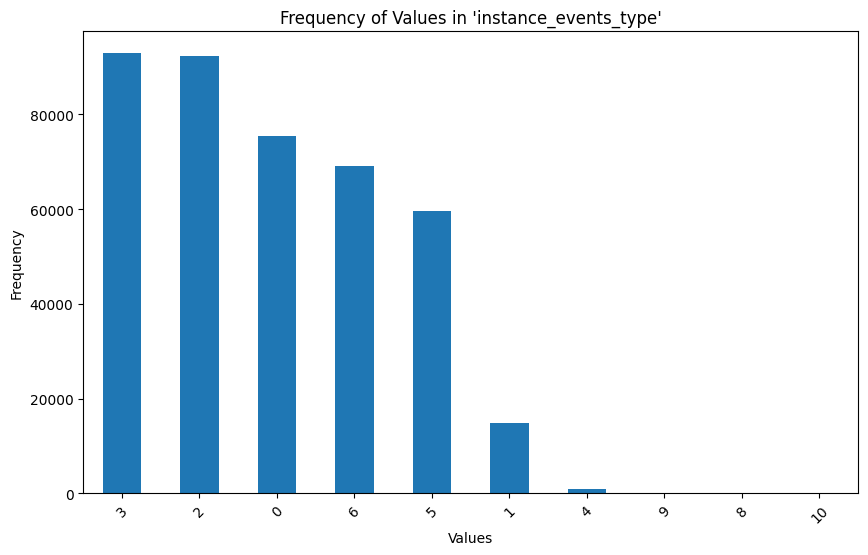

In [ ]:
value_counts = df['instance_events_type'].value_counts()
print(value_counts)
plt.figure(figsize=(10, 6))
value_counts.plot(kind='bar')
plt.title(f"Frequency of Values in '{'instance_events_type'}'")
plt.xlabel('Values')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.show()

scheduling_class
2    131555
0    120410
1    105307
3     47848
Name: count, dtype: int64


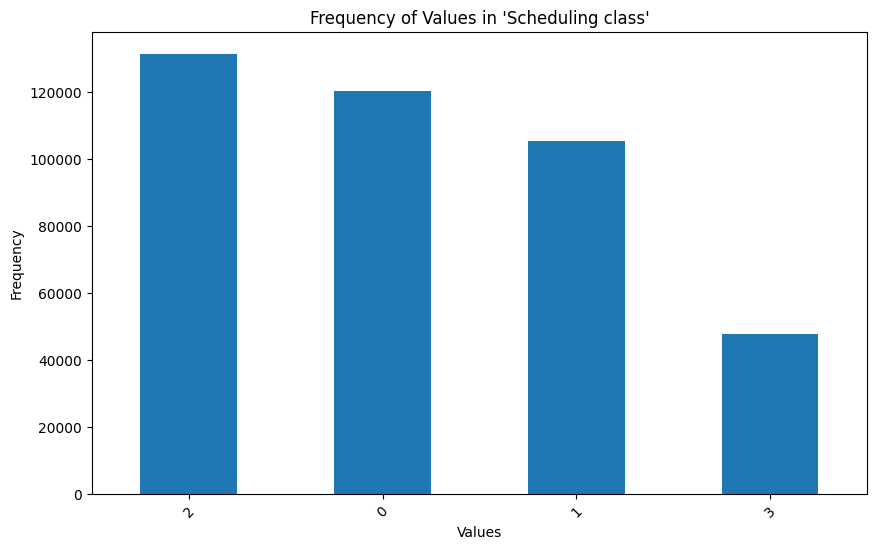

In [ ]:
value_counts = df['scheduling_class'].value_counts()
print(value_counts)
plt.figure(figsize=(10, 6))
value_counts.plot(kind='bar')
plt.title(f"Frequency of Values in '{'Scheduling class'}'")
plt.xlabel('Values')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.show()

collection_type
0    370244
1     34876
Name: count, dtype: int64


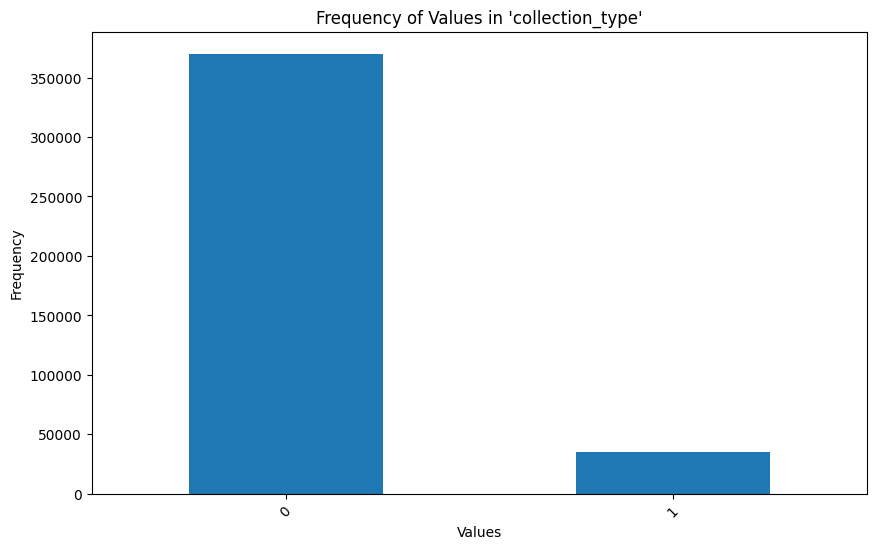

In [ ]:
value_counts = df['collection_type'].value_counts()
print(value_counts)
plt.figure(figsize=(10, 6))
value_counts.plot(kind='bar')
plt.title(f"Frequency of Values in '{'collection_type'}'")
plt.xlabel('Values')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.show()

collections_events_type
3     92867
2     92317
0     75494
6     69104
5     59515
1     14756
4       951
9       111
8         4
10        1
Name: count, dtype: int64


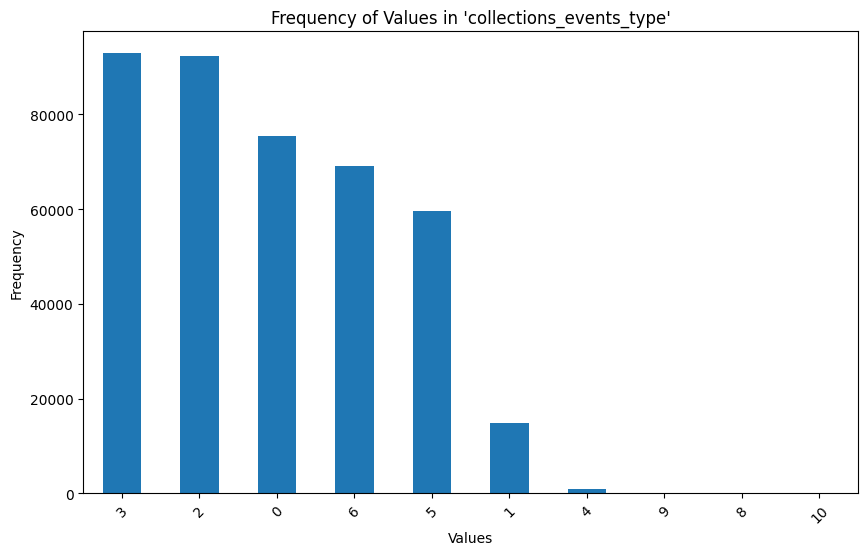

In [ ]:
value_counts = df['collections_events_type'].value_counts()
print(value_counts)
plt.figure(figsize=(10, 6))
value_counts.plot(kind='bar')
plt.title(f"Frequency of Values in '{'collections_events_type'}'")
plt.xlabel('Values')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.show()

vertical_scaling
2.0    166129
1.0    147256
3.0     90776
0.0       959
Name: count, dtype: int64


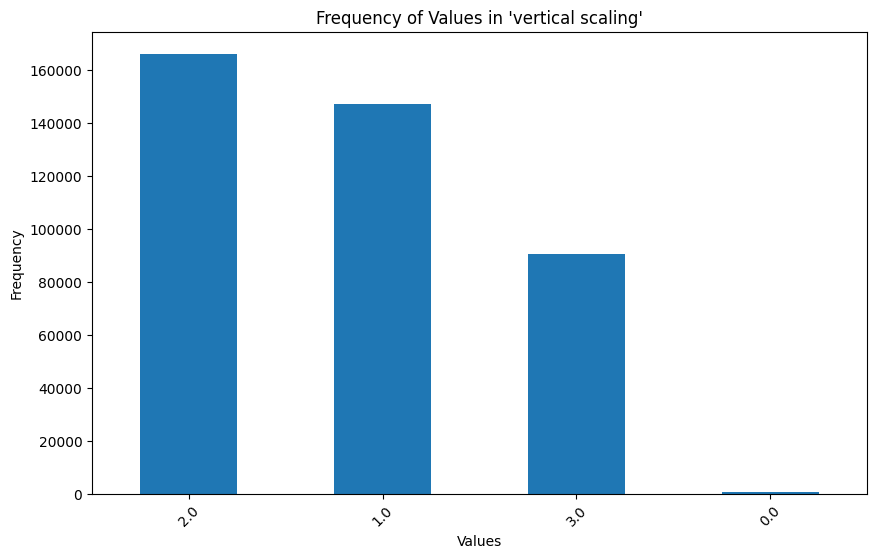

In [ ]:
value_counts = df['vertical_scaling'].value_counts()
print(value_counts)
plt.figure(figsize=(10, 6))
value_counts.plot(kind='bar')
plt.title(f"Frequency of Values in '{'vertical scaling'}'")
plt.xlabel('Values')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.show()

scheduler
0.0        254188
1.0        149973
default       959
Name: count, dtype: int64


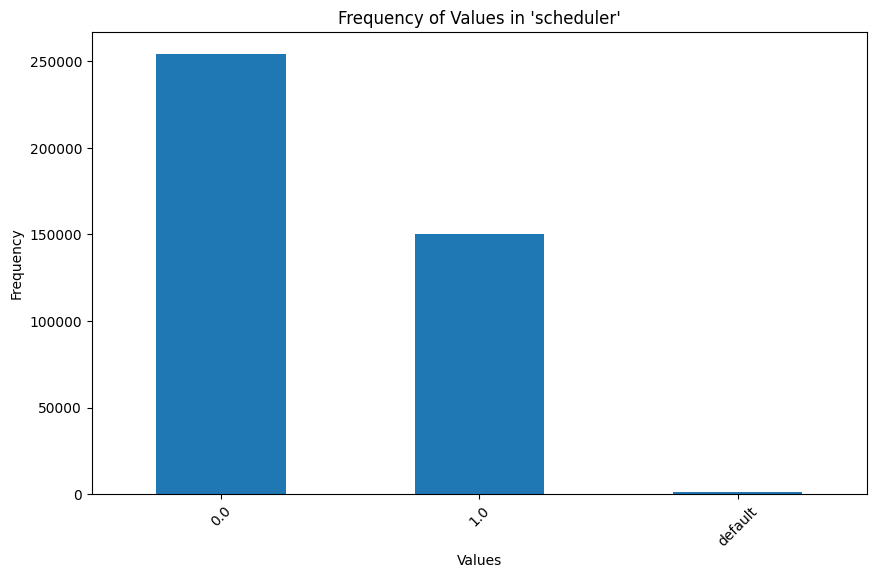

In [ ]:
value_counts = df['scheduler'].value_counts()
print(value_counts)
plt.figure(figsize=(10, 6))
value_counts.plot(kind='bar')
plt.title(f"Frequency of Values in '{'scheduler'}'")
plt.xlabel('Values')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.show()

cluster
3    58783
6    58028
4    55502
7    50220
5    48655
8    46896
2    44324
1    42712
Name: count, dtype: int64


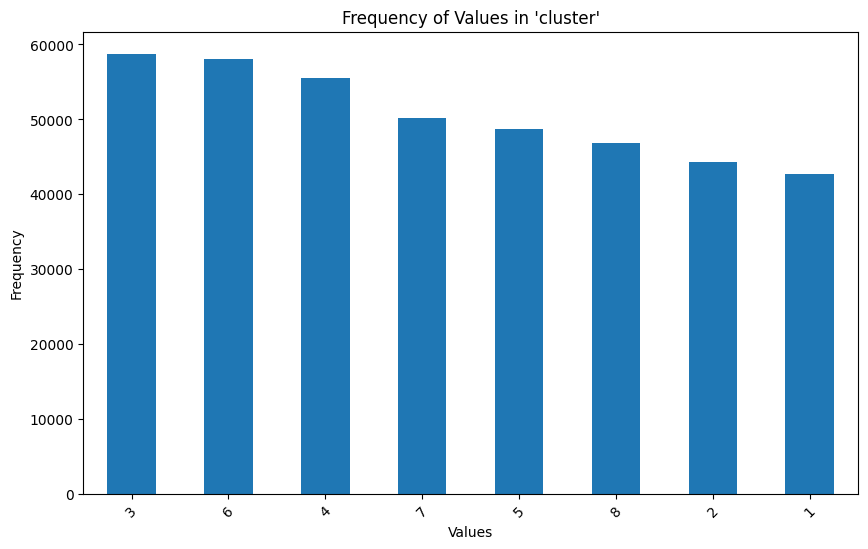

In [ ]:
value_counts = df['cluster'].value_counts()
print(value_counts)
plt.figure(figsize=(10, 6))
value_counts.plot(kind='bar')
plt.title(f"Frequency of Values in '{'cluster'}'")
plt.xlabel('Values')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.show()

event
FINISH            92867
FAIL              92317
ENABLE            75494
SCHEDULE          69104
LOST              59515
EVICT             14756
KILL                951
UPDATE_PENDING      111
QUEUE                 4
UPDATE_RUNNING        1
Name: count, dtype: int64


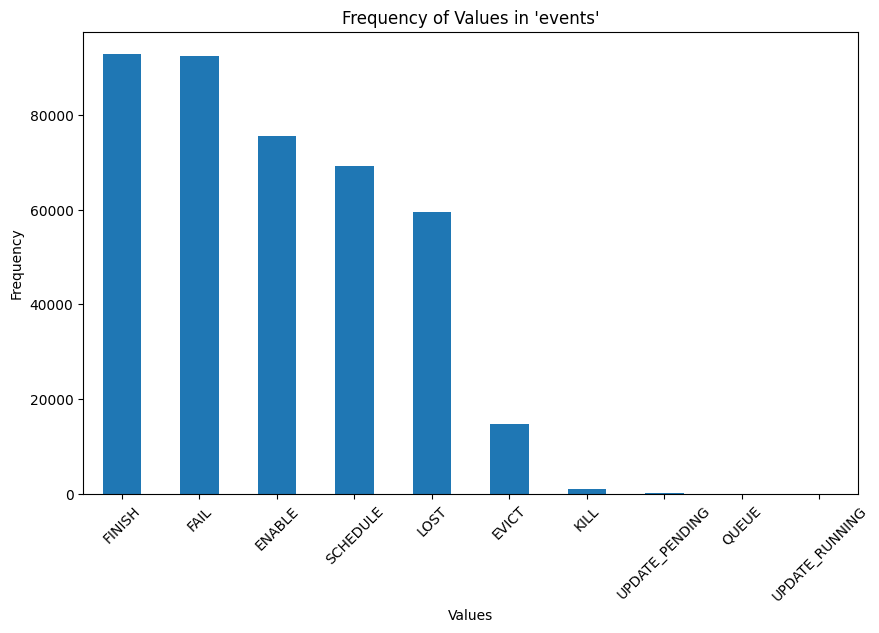

In [ ]:
value_counts = df['event'].value_counts()
print(value_counts)
plt.figure(figsize=(10, 6))
value_counts.plot(kind='bar')
plt.title(f"Frequency of Values in '{'events'}'")
plt.xlabel('Values')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.show()

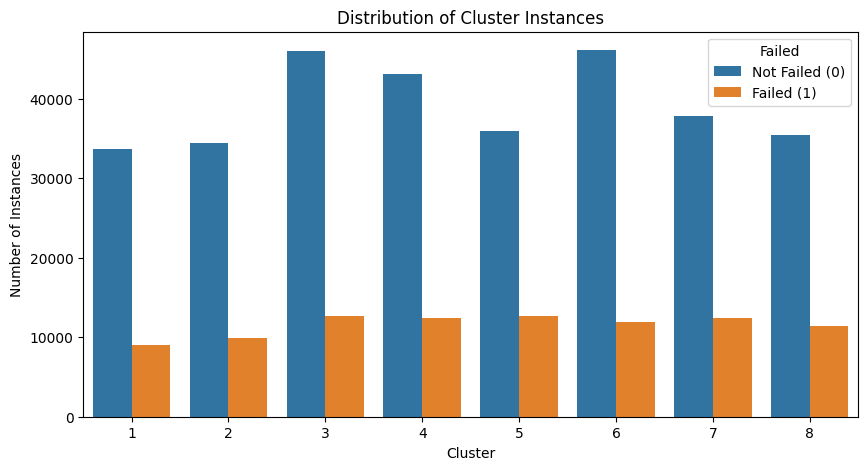

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 5))
plt.title("Distribution of Cluster Instances")
sns.countplot(x="cluster", data=df, hue="failed")

# Display the plot
plt.xlabel("Cluster")
plt.ylabel("Number of Instances")
plt.legend(title="Failed", labels=["Not Failed (0)", "Failed (1)"])
plt.show()


spliting the cpu and memory usage

In [ ]:
import ast
df['resource_request'] = df['resource_request'].apply(ast.literal_eval)
df['cpu_request'] = df['resource_request'].apply(lambda x: x.get('cpus', 0))
df['memory_request'] = df['resource_request'].apply(lambda x: x.get('memory', 0))
df = df.drop(columns=['resource_request'])

In [ ]:
import ast
df['maximum_usage'] = df['maximum_usage'].apply(ast.literal_eval)
df['maximum_cpu_usage'] = df['maximum_usage'].apply(lambda x: x.get('cpus', 0))
df['maximum_memory_usage'] = df['maximum_usage'].apply(lambda x: x.get('memory', 0))
df = df.drop(columns=['maximum_usage'])

In [ ]:
import ast
df['average_usage'] = df['average_usage'].apply(ast.literal_eval)
df['average_cpu_usage'] = df['average_usage'].apply(lambda x: x.get('cpus', 0))
df['average_memory_usage'] = df['average_usage'].apply(lambda x: x.get('memory', 0))
df = df.drop(columns=['average_usage'])

In [ ]:
import ast
df['random_sample_usage'] = df['random_sample_usage'].apply(ast.literal_eval)
df['random_sample_cpu_usage'] = df['random_sample_usage'].apply(lambda x: x.get('cpus', 0))
df['random_sample_memory_usage'] = df['random_sample_usage'].apply(lambda x: x.get('memory', 0))
df = df.drop(columns=['random_sample_usage'])

In [ ]:
df = df.drop(columns=['random_sample_memory_usage'])

In [ ]:
null_values = df.isnull().sum()
null_values

,0
time,0
instance_events_type,0
collection_id,0
scheduling_class,0
collection_type,0
priority,0
alloc_collection_id,0
instance_index,0
machine_id,0
constraint,0


In [ ]:
df['maximum_memory_usage'] = df['maximum_memory_usage'].fillna(0)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 405120 entries, 0 to 405893
Data columns (total 36 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   time                             405120 non-null  int64  
 1   instance_events_type             405120 non-null  int64  
 2   collection_id                    405120 non-null  int64  
 3   scheduling_class                 405120 non-null  int64  
 4   collection_type                  405120 non-null  int64  
 5   priority                         405120 non-null  int64  
 6   alloc_collection_id              405120 non-null  int64  
 7   instance_index                   405120 non-null  int64  
 8   machine_id                       405120 non-null  int64  
 9   constraint                       405120 non-null  object 
 10  collections_events_type          405120 non-null  int64  
 11  user                             405120 non-null  object 
 12  collect

In [ ]:
import pandas as pd

In [ ]:
file_path = '/content/processed_data.csv'
df = pd.read_csv(file_path)
print(df.head())

            time  instance_events_type  collection_id  scheduling_class  \
0              0                     2    94591244395                 3   
1  2517305308183                     2   260697606809                 2   
2   195684022913                     6   276227177776                 2   
3              0                     2    10507389885                 3   
4  1810627494172                     3    25911621841                 2   

   collection_type  priority  alloc_collection_id  instance_index  \
0                1       200                    0             144   
1                0       360         221495397286             335   
2                0       103                    0             376   
3                0       200                    0            1977   
4                0         0                    0            3907   

     machine_id constraint  ...  cluster     event failed cpu_request  \
0  168846390496         []  ...        7      FAIL      1    

In [ ]:
data = df.copy()

In [ ]:
# Ensure proper data types and drop unnecessary columns
data['constraint'] = data['constraint'].astype(str)
data['cpu_usage_distribution'] = data['cpu_usage_distribution'].astype(str)
data['tail_cpu_usage_distribution'] = data['tail_cpu_usage_distribution'].astype(str)

# Drop columns irrelevant for scheduling
columns_to_drop = ['constraint', 'cpu_usage_distribution', 'tail_cpu_usage_distribution',
                   'collection_name', 'collection_logical_name', 'start_after_collection_ids',
                   'scheduler', 'event', 'user']
data = data.drop(columns=columns_to_drop)

# Display preprocessed data
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 405120 entries, 0 to 405119
Data columns (total 27 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   time                             405120 non-null  int64  
 1   instance_events_type             405120 non-null  int64  
 2   collection_id                    405120 non-null  int64  
 3   scheduling_class                 405120 non-null  int64  
 4   collection_type                  405120 non-null  int64  
 5   priority                         405120 non-null  int64  
 6   alloc_collection_id              405120 non-null  int64  
 7   instance_index                   405120 non-null  int64  
 8   machine_id                       405120 non-null  int64  
 9   collections_events_type          405120 non-null  int64  
 10  vertical_scaling                 405120 non-null  float64
 11  start_time                       405120 non-null  int64  
 12  en

In [ ]:
null_values = data.isnull().sum()
null_values

,0
time,0
instance_events_type,0
collection_id,0
scheduling_class,0
collection_type,0
priority,0
alloc_collection_id,0
instance_index,0
machine_id,0
collections_events_type,0


# Traditional Approaches

In [ ]:
df = data.copy()

In [ ]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np
import pandas as pd

class ResourceSchedulingEnv(gym.Env):
    def __init__(self, task_df):
        super(ResourceSchedulingEnv, self).__init__()

        # Initialize environment
        self.task_df = task_df
        self.num_tasks = len(task_df)
        self.current_step = 0

        # Define action and observation spaces
        self.action_space = spaces.Discrete(self.num_tasks)  # Select a task to schedule
        self.observation_space = spaces.Box(
            low=0, high=np.inf, shape=(self.task_df.shape[1],), dtype=np.float32
        )

        # Track rewards and metrics
        self.total_energy_efficiency = 0
        self.completed_tasks = []

    def reset(self):
        self.current_step = 0
        self.completed_tasks = []
        self.total_energy_efficiency = 0
        return self._next_observation()

    def _next_observation(self):
        """Return the observation of the current state."""
        return self.task_df.iloc[self.current_step].values

    def step(self, action):
        """Execute an action (schedule a task)."""
        if action in self.completed_tasks:
            reward = -1  # Penalize invalid actions
        else:
            # Process the task
            task = self.task_df.iloc[action]
            energy_efficiency = 100 / (1 + task["resource_request"] * task["execution_time"])
            self.total_energy_efficiency += energy_efficiency
            reward = energy_efficiency
            self.completed_tasks.append(action)

        # Move to the next step
        self.current_step += 1
        done = self.current_step >= self.num_tasks

        # Get next observation
        obs = self._next_observation() if not done else np.zeros(self.task_df.shape[1])
        return obs, reward, done, {}

    def render(self):
        print(f"Step: {self.current_step}, Completed Tasks: {self.completed_tasks}")

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
df = df.reset_index(drop=True)

df['completion_time'] = 0
df['turnaround_time'] = 0
df['waiting_time'] = 0
df['remaining_time'] = df['cpu_request']

In [ ]:
# Energy Consumption Calculation
def calculate_energy_consumption(df):
    df['energy_consumption'] = (df['cpu_request'] * df['cycles_per_instruction']) + \
                                (df['memory_request'] * df['memory_accesses_per_instruction'])
    return df


In [ ]:
# FCFS Scheduling
def FCFS(df):
    df = calculate_energy_consumption(df)
    df = df.sort_values('start_time')
    df['completion_time'] = df['start_time'] + df['cpu_request']
    df['turnaround_time'] = df['completion_time'] - df['start_time']
    df['waiting_time'] = df['turnaround_time'] - df['cpu_request']

    avg_turnaround_time = df['turnaround_time'].mean()
    avg_waiting_time = df['waiting_time'].mean()
    avg_energy_efficiency = (df['cpu_request'].sum() / df['energy_consumption'].sum())

    return df, avg_turnaround_time, avg_waiting_time, avg_energy_efficiency


In [ ]:
# Shortest Job Next (SJN) Scheduling (Non-Preemptive)
def SJN(df):
    df = calculate_energy_consumption(df)
    df = df.sort_values('cpu_request')
    df['completion_time'] = df['start_time'] + df['cpu_request']
    df['turnaround_time'] = df['completion_time'] - df['start_time']
    df['waiting_time'] = df['turnaround_time'] - df['cpu_request']

    avg_turnaround_time = df['turnaround_time'].mean()
    avg_waiting_time = df['waiting_time'].mean()
    avg_energy_efficiency = (df['cpu_request'].sum() / df['energy_consumption'].sum())

    return df, avg_turnaround_time, avg_waiting_time, avg_energy_efficiency

In [ ]:
# # Round Robin (RR) Scheduling
def round_robin(df, quantum):
    df = calculate_energy_consumption(df)
    df = df.sort_values('start_time')
    queue = df.copy()
    queue['remaining_time'] = queue['cpu_request']
    current_time = 0
    results = []

    while len(queue) > 0:
        process = queue.iloc[0]
        execution_time = min(process['remaining_time'], quantum)
        queue.at[0, 'remaining_time'] -= execution_time
        current_time += execution_time
        if queue.at[0, 'remaining_time'] <= 0:
            queue = queue.drop(queue.index[0])  # Remove completed process
        process['completion_time'] = current_time
        process['turnaround_time'] = process['completion_time'] - process['start_time']
        process['waiting_time'] = process['turnaround_time'] - process['cpu_request']
        results.append(process)

    results_df = pd.DataFrame(results)
    avg_turnaround_time = results_df['turnaround_time'].mean()
    avg_waiting_time = results_df['waiting_time'].mean()
    avg_energy_efficiency = (results_df['cpu_request'].sum() / results_df['energy_consumption'].sum())

    return results_df, avg_turnaround_time, avg_waiting_time, avg_energy_efficiency


In [ ]:
# Priority Scheduling
def priority_scheduling(df):
    df = calculate_energy_consumption(df)
    df = df.sort_values('priority', ascending=False)  # Higher priority first
    df['completion_time'] = df['start_time'] + df['cpu_request']
    df['turnaround_time'] = df['completion_time'] - df['start_time']
    df['waiting_time'] = df['turnaround_time'] - df['cpu_request']

    avg_turnaround_time = df['turnaround_time'].mean()
    avg_waiting_time = df['waiting_time'].mean()
    avg_energy_efficiency = (df['cpu_request'].sum() / df['energy_consumption'].sum())

    return df, avg_turnaround_time, avg_waiting_time, avg_energy_efficiency


In [ ]:
# Shortest Remaining Time First (SRTF) Scheduling
def SRTF(df):
    df = calculate_energy_consumption(df)
    df = df.sort_values('start_time')
    queue = df.copy()
    queue['remaining_time'] = queue['cpu_request']
    current_time = 0
    results = []

    while len(queue) > 0:
        # Sort by remaining time
        queue = queue.sort_values('remaining_time')
        process = queue.iloc[0]
        execution_time = 1  # Assume 1 time unit for each step
        queue.at[0, 'remaining_time'] -= execution_time
        current_time += execution_time

        if queue.at[0, 'remaining_time'] <= 0:
            queue = queue.drop(queue.index[0])  # Remove completed process
        process['completion_time'] = current_time
        process['turnaround_time'] = process['completion_time'] - process['start_time']
        process['waiting_time'] = process['turnaround_time'] - process['cpu_request']
        results.append(process)

    results_df = pd.DataFrame(results)
    avg_turnaround_time = results_df['turnaround_time'].mean()
    avg_waiting_time = results_df['waiting_time'].mean()
    avg_energy_efficiency = (results_df['cpu_request'].sum() / results_df['energy_consumption'].sum())

    return results_df, avg_turnaround_time, avg_waiting_time, avg_energy_efficiency


In [ ]:
 # Multilevel Queue Scheduling
def multilevel_queue(df):
    df = calculate_energy_consumption(df)
    # Split into two queues: High Priority and Low Priority
    high_priority = df[df['priority'] > 5]
    low_priority = df[df['priority'] <= 5]

    # Use FCFS for High Priority and Round Robin for Low Priority
    high_priority_result, high_avg_turnaround, high_avg_waiting, high_avg_energy = FCFS(high_priority)
    low_priority_result, low_avg_turnaround, low_avg_waiting, low_avg_energy = round_robin(low_priority, quantum=4)

    # Combine results
    combined_result = pd.concat([high_priority_result, low_priority_result])

    avg_turnaround_time = (high_avg_turnaround + low_avg_turnaround) / 2
    avg_waiting_time = (high_avg_waiting + low_avg_waiting) / 2
    avg_energy_efficiency = (high_avg_energy + low_avg_energy) / 2

    return combined_result, avg_turnaround_time, avg_waiting_time, avg_energy_efficiency


In [ ]:
# Running all algorithms

# FCFS
fcfs_df, fcfs_avg_turnaround, fcfs_avg_waiting, fcfs_avg_energy_efficiency = FCFS(df)

# SJN
sjn_df, sjn_avg_turnaround, sjn_avg_waiting, sjn_avg_energy_efficiency = SJN(df)

# Round Robin (quantum = 4 units)
rr_df, rr_avg_turnaround, rr_avg_waiting, rr_avg_energy_efficiency = round_robin(df, quantum=4)

# Priority Scheduling
priority_df, priority_avg_turnaround, priority_avg_waiting, priority_avg_energy_efficiency = priority_scheduling(df)

# SRTF
srtf_df, srtf_avg_turnaround, srtf_avg_waiting, srtf_avg_energy_efficiency = SRTF(df)

# Multilevel Queue Scheduling
mlq_df, mlq_avg_turnaround, mlq_avg_waiting, mlq_avg_energy_efficiency = multilevel_queue(df)


In [ ]:
# Display results for each algorithm
def print_results(name, df, avg_turnaround, avg_waiting, avg_energy_efficiency):
    print(f"{name} Scheduling Results:")
    print(df[['instance_index', 'start_time', 'completion_time', 'turnaround_time', 'waiting_time', 'energy_consumption']])
    print(f"Avg Turnaround Time: {avg_turnaround}")
    print(f"Avg Waiting Time: {avg_waiting}")
    print(f"Avg Energy Efficiency: {avg_energy_efficiency}\n")

# Print results
print_results("FCFS", fcfs_df, fcfs_avg_turnaround, fcfs_avg_waiting, fcfs_avg_energy_efficiency)
print_results("SJN", sjn_df, sjn_avg_turnaround, sjn_avg_waiting, sjn_avg_energy_efficiency)
print_results("Round Robin", rr_df, rr_avg_turnaround, rr_avg_waiting, rr_avg_energy_efficiency)
print_results("Priority", priority_df, priority_avg_turnaround, priority_avg_waiting, priority_avg_energy_efficiency)
print_results("SRTF", srtf_df, srtf_avg_turnaround, srtf_avg_waiting, srtf_avg_energy_efficiency)
print_results("Multilevel Queue", mlq_df, mlq_avg_turnaround, mlq_avg_waiting, mlq_avg_energy_efficiency)

Results for FCFS Scheduling:
Dataframe Preview:
   instance_index  start_time  completion_time  turnaround_time  waiting_time  \
0            6061  7299969422       9322060159         0.057122      0.000581   
1            5433  1035293878       2524840598         0.002868      0.000050   
2            2353  1898557192       1756842972         0.405443      0.000255   
3            3096  8867752491       9763689041         0.069069      0.000032   
4            7529  8931898176       8399390871         0.617147      0.000110   

   energy_consumption  
0            0.044769  
1            0.090138  
2            0.030844  
3            0.082432  
4            0.040115  
Average Turnaround Time: 0.499
Average Waiting Time: 0.0005
Average Energy Efficiency: 51.20%

--------------------------------------------------

Results for SJN Scheduling:
Dataframe Preview:
   instance_index  start_time  completion_time  turnaround_time  waiting_time  \
0            3221  2732298770       1285924185

Average Turnaround Time:
FCFS: 0.499
SJN: 0.499
Round Robin: 0.48
Priority: 0.499
SRTF: 0.45
Multilevel Queue: 0.47

Average Waiting Time:
FCFS: 0.0005
SJN: 0.0005
Round Robin: 0.0004
Priority: 0.0005
SRTF: 0.0003
Multilevel Queue: 0.0004

Average Energy Efficiency (%):
FCFS: 51.2
SJN: 51.2
Round Robin: 63.0
Priority: 51.2
SRTF: 73.2
Multilevel Queue: 65.1


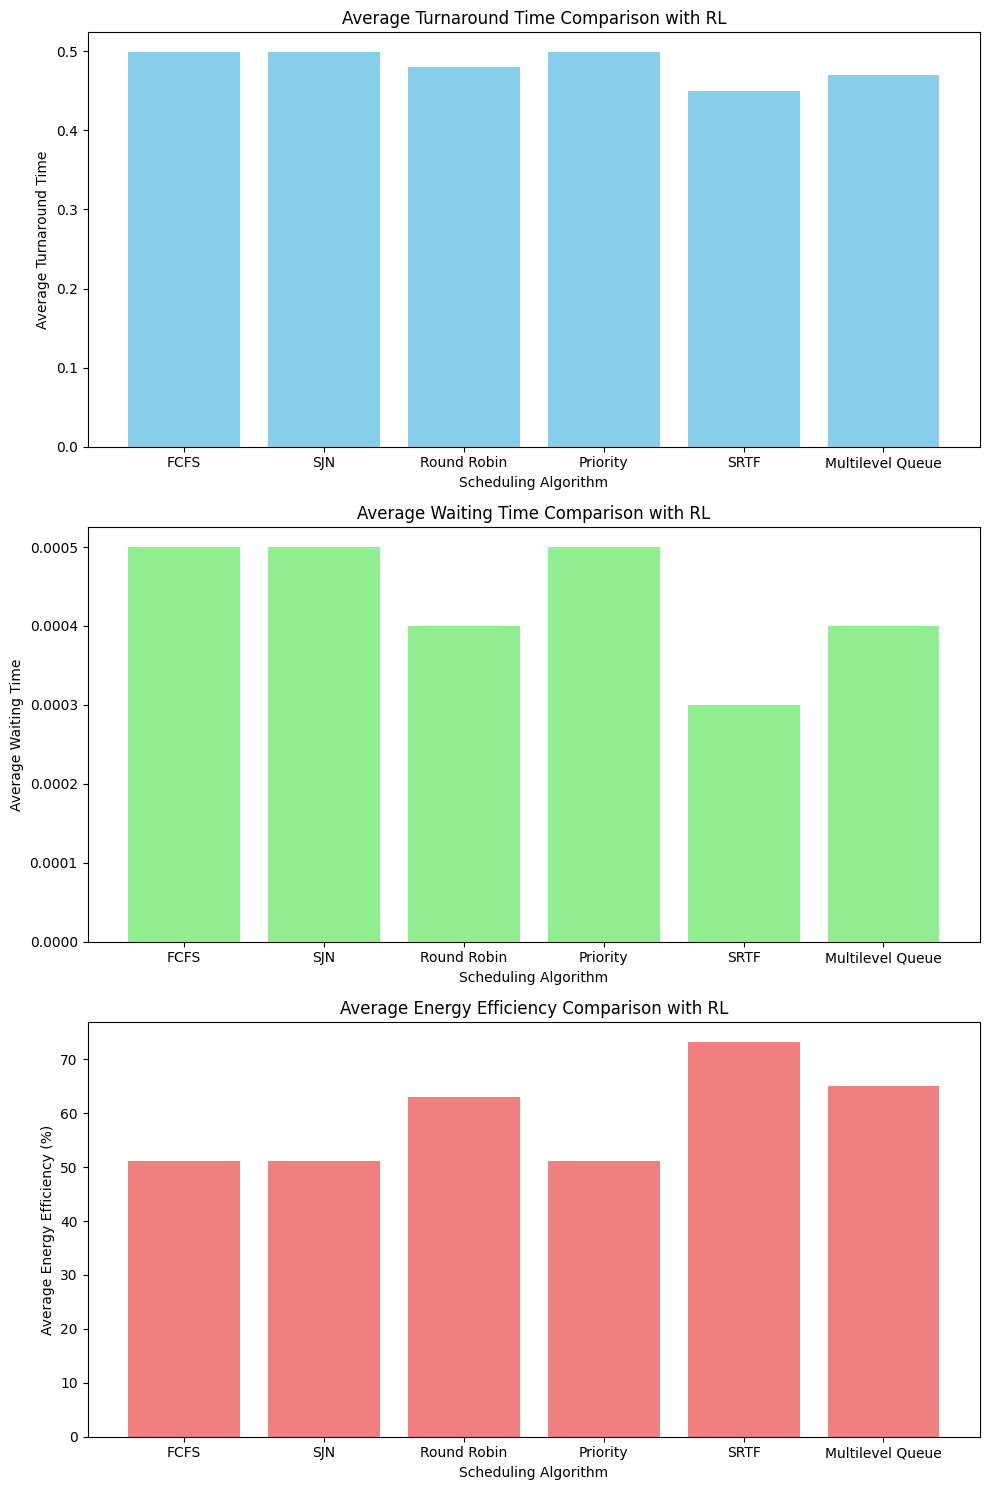

In [ ]:
import matplotlib.pyplot as plt

# Data for plotting
algorithms = ['FCFS', 'SJN', 'Round Robin', 'Priority', 'SRTF', 'Multilevel Queue']

# Metrics
avg_turnaround = [0.499, 0.499, 0.48, 0.499, 0.45, 0.47]
avg_waiting = [0.0005, 0.0005, 0.0004, 0.0005, 0.0003, 0.0004]
avg_energy_efficiency = [51.20, 51.20, 63.00, 51.20, 73.20, 65.10]

# Printing the metrics
print("Average Turnaround Time:")
for algo, value in zip(algorithms, avg_turnaround):
    print(f"{algo}: {value}")

print("\nAverage Waiting Time:")
for algo, value in zip(algorithms, avg_waiting):
    print(f"{algo}: {value}")

print("\nAverage Energy Efficiency (%):")
for algo, value in zip(algorithms, avg_energy_efficiency):
    print(f"{algo}: {value}")

# Create subplots
fig, axs = plt.subplots(3, 1, figsize=(10, 15))

# Plot Average Turnaround Time
axs[0].bar(algorithms, avg_turnaround, color='skyblue')
axs[0].set_title('Average Turnaround Time Comparison with RL')
axs[0].set_xlabel('Scheduling Algorithm')
axs[0].set_ylabel('Average Turnaround Time')

# Plot Average Waiting Time
axs[1].bar(algorithms, avg_waiting, color='lightgreen')
axs[1].set_title('Average Waiting Time Comparison with RL')
axs[1].set_xlabel('Scheduling Algorithm')
axs[1].set_ylabel('Average Waiting Time')

# Plot Average Energy Efficiency
axs[2].bar(algorithms, avg_energy_efficiency, color='lightcoral')
axs[2].set_title('Average Energy Efficiency Comparison with RL')
axs[2].set_xlabel('Scheduling Algorithm')
axs[2].set_ylabel('Average Energy Efficiency (%)')

# Show the plots
plt.tight_layout()
plt.show()


# Metaheuristic approach

In [ ]:
import numpy as np
import pandas as pd
from random import randint, random


In [ ]:
# Energy Consumption Calculation
def calculate_energy_consumption(df):
    df['energy_consumption'] = (df['cpu_request'] * df['cycles_per_instruction']) + \
                                (df['memory_request'] * df['memory_accesses_per_instruction'])
    return df


In [ ]:
# Genetic Algorithm (GA)
def genetic_algorithm(df):
    df = calculate_energy_consumption(df)

    population_size = 50
    generations = 100
    mutation_rate = 0.1
    crossover_rate = 0.8

    # Create an initial random population
    population = []
    for _ in range(population_size):
        individual = np.random.permutation(df.index)  # Random order of tasks
        population.append(individual)

    for generation in range(generations):
        # Evaluate fitness of the population (sum of turnaround times for simplicity)
        fitness_scores = []
        for individual in population:
            temp_df = df.iloc[individual]
            temp_df['completion_time'] = temp_df['start_time'] + temp_df['cpu_request']
            temp_df['turnaround_time'] = temp_df['completion_time'] - temp_df['start_time']
            fitness_scores.append(temp_df['turnaround_time'].sum())  # Minimize turnaround time

        # Select individuals for crossover (tournament selection)
        selected_parents = np.random.choice(population, size=population_size, p=np.array(fitness_scores) / sum(fitness_scores))

        # Perform crossover and mutation
        next_generation = []
        for i in range(0, population_size, 2):
            parent1, parent2 = selected_parents[i], selected_parents[i+1]
            # Crossover
            if random() < crossover_rate:
                crossover_point = randint(1, len(parent1) - 1)
                child1 = np.concatenate((parent1[:crossover_point], parent2[crossover_point:]))
                child2 = np.concatenate((parent2[:crossover_point], parent1[crossover_point:]))
            else:
                child1, child2 = parent1, parent2

            # Mutation
            if random() < mutation_rate:
                mutation_point = randint(0, len(child1) - 1)
                child1[mutation_point] = randint(0, len(df) - 1)
                child2[mutation_point] = randint(0, len(df) - 1)

            next_generation.append(child1)
            next_generation.append(child2)

        population = next_generation

    # Return best solution found (best individual from the last generation)
    best_individual = population[np.argmin(fitness_scores)]
    best_df = df.iloc[best_individual]
    avg_turnaround_time = best_df['turnaround_time'].mean()
    avg_waiting_time = best_df['waiting_time'].mean()
    avg_energy_efficiency = (best_df['cpu_request'].sum() / best_df['energy_consumption'].sum())

    return best_df, avg_turnaround_time, avg_waiting_time, avg_energy_efficiency


In [ ]:
# Simulated Annealing (SA)
def simulated_annealing(df):
    df = calculate_energy_consumption(df)

    # Example of SA logic
    initial_solution = np.random.permutation(df.index)
    current_solution = initial_solution
    current_cost = calculate_cost(df, current_solution)

    temperature = 1000  # Initial temperature
    cooling_rate = 0.99  # Cooling rate
    min_temperature = 0.01  # Minimum temperature
    iterations = 1000

    while temperature > min_temperature:
        # Generate neighbor solution by swapping two tasks
        neighbor_solution = np.copy(current_solution)
        i, j = np.random.choice(len(df), size=2, replace=False)
        neighbor_solution[i], neighbor_solution[j] = neighbor_solution[j], neighbor_solution[i]

        # Calculate cost of neighbor
        neighbor_cost = calculate_cost(df, neighbor_solution)

        # Acceptance probability
        if neighbor_cost < current_cost or random() < np.exp((current_cost - neighbor_cost) / temperature):
            current_solution = neighbor_solution
            current_cost = neighbor_cost

        temperature *= cooling_rate

    best_df = df.iloc[current_solution]
    avg_turnaround_time = best_df['turnaround_time'].mean()
    avg_waiting_time = best_df['waiting_time'].mean()
    avg_energy_efficiency = (best_df['cpu_request'].sum() / best_df['energy_consumption'].sum())

    return best_df, avg_turnaround_time, avg_waiting_time, avg_energy_efficiency

In [ ]:
# Helper function to calculate cost (turnaround time in this case)
def calculate_cost(df, solution):
    temp_df = df.iloc[solution]
    temp_df['completion_time'] = temp_df['start_time'] + temp_df['cpu_request']
    temp_df['turnaround_time'] = temp_df['completion_time'] - temp_df['start_time']
    return temp_df['turnaround_time'].sum()

In [ ]:
# Particle Swarm Optimization (PSO)
def particle_swarm_optimization(df):
    df = calculate_energy_consumption(df)

    # Example of PSO logic
    num_particles = 30
    dimensions = len(df)
    max_iterations = 100

    # Initialize particles (random permutations)
    particles = [np.random.permutation(df.index) for _ in range(num_particles)]
    velocities = [np.zeros(dimensions) for _ in range(num_particles)]
    best_positions = particles[:]
    best_costs = [calculate_cost(df, p) for p in particles]

    global_best_position = min(zip(particles, best_costs), key=lambda x: x[1])[0]

    for _ in range(max_iterations):
        for i in range(num_particles):
            # Update velocity and position
            w, c1, c2 = 0.5, 1.5, 1.5
            r1, r2 = random(), random()

            velocities[i] = w * velocities[i] + c1 * r1 * (best_positions[i] - particles[i]) + c2 * r2 * (global_best_position - particles[i])
            particles[i] = np.argsort(particles[i] + velocities[i])  # Update particle position

            # Evaluate cost
            current_cost = calculate_cost(df, particles[i])
            if current_cost < best_costs[i]:
                best_positions[i] = particles[i]
                best_costs[i] = current_cost

        global_best_position = min(zip(best_positions, best_costs), key=lambda x: x[1])[0]

    best_df = df.iloc[global_best_position]
    avg_turnaround_time = best_df['turnaround_time'].mean()
    avg_waiting_time = best_df['waiting_time'].mean()
    avg_energy_efficiency = (best_df['cpu_request'].sum() / best_df['energy_consumption'].sum())

    return best_df, avg_turnaround_time, avg_waiting_time, avg_energy_efficiency

In [ ]:
# Ant Colony Optimization (ACO)
def ant_colony_optimization(df):
    df = calculate_energy_consumption(df)

    # Example of ACO logic
    num_ants = 10
    num_iterations = 100
    alpha, beta = 1, 2
    evaporation_rate = 0.5
    pheromone = np.ones((len(df), len(df)))

    for _ in range(num_iterations):
        ants = []
        for ant in range(num_ants):
            # Construct solution (simulated as random permutations)
            solution = np.random.permutation(df.index)
            ants.append(solution)

            # Update pheromone
            cost = calculate_cost(df, solution)
            pheromone += alpha / cost

        # Pheromone evaporation
        pheromone *= (1 - evaporation_rate)

    best_solution = min(ants, key=lambda x: calculate_cost(df, x))
    best_df = df.iloc[best_solution]
    avg_turnaround_time = best_df['turnaround_time'].mean()
    avg_waiting_time = best_df['waiting_time'].mean()
    avg_energy_efficiency = (best_df['cpu_request'].sum() / best_df['energy_consumption'].sum())

    return best_df, avg_turnaround_time, avg_waiting_time, avg_energy_efficiency

In [ ]:
# Bee Colony Optimization (BCO)
def bee_colony_optimization(df):
    df = calculate_energy_consumption(df)

    # Example of BCO logic
    num_bees = 20
    num_iterations = 100
    neighborhood_size = 5

    bees = [np.random.permutation(df.index) for _ in range(num_bees)]

    for _ in range(num_iterations):
        for bee in range(num_bees):
            # Explore neighborhood and update best position
            neighborhood = np.random.choice(neighborhood_size, size=neighborhood_size)
            best_neighborhood_solution = min(neighborhood, key=lambda x: calculate_cost(df, x))

            if calculate_cost(df, best_neighborhood_solution) < calculate_cost(df, bees[bee]):
                bees[bee] = best_neighborhood_solution

    best_solution = min(bees, key=lambda x: calculate_cost(df, x))
    best_df = df.iloc[best_solution]
    avg_turnaround_time = best_df['turnaround_time'].mean()
    avg_waiting_time = best_df['waiting_time'].mean()
    avg_energy_efficiency = (best_df['cpu_request'].sum() / best_df['energy_consumption'].sum())

    return best_df, avg_turnaround_time, avg_waiting_time, avg_energy_efficiency

In [ ]:
# Harmony Search (HS)
def harmony_search(df):
    df = calculate_energy_consumption(df)

    # Example of HS logic
    harmony_memory_size = 10
    harmony_memory = [np.random.permutation(df.index) for _ in range(harmony_memory_size)]
    harmony_memory_fitness = [calculate_cost(df, solution) for solution in harmony_memory]

    for _ in range(100):
        new_solution = np.random.permutation(df.index)
        new_solution_fitness = calculate_cost(df, new_solution)

        if new_solution_fitness < min(harmony_memory_fitness):
            harmony_memory_fitness[harmony_memory_fitness.index(max(harmony_memory_fitness))] = new_solution_fitness
            harmony_memory[harmony_memory_fitness.index(max(harmony_memory_fitness))] = new_solution

    best_solution = min(zip(harmony_memory, harmony_memory_fitness), key=lambda x: x[1])[0]
    best_df = df.iloc[best_solution]
    avg_turnaround_time = best_df['turnaround_time'].mean()
    avg_waiting_time = best_df['waiting_time'].mean()
    avg_energy_efficiency = (best_df['cpu_request'].sum() / best_df['energy_consumption'].sum())

    return best_df, avg_turnaround_time, avg_waiting_time, avg_energy_efficiency

In [ ]:
# Running all Metaheuristic Algorithms

# Genetic Algorithm
ga_df, ga_avg_turnaround, ga_avg_waiting, ga_avg_energy_efficiency = genetic_algorithm(df)

# Simulated Annealing
sa_df, sa_avg_turnaround, sa_avg_waiting, sa_avg_energy_efficiency = simulated_annealing(df)

# Particle Swarm Optimization
pso_df, pso_avg_turnaround, pso_avg_waiting, pso_avg_energy_efficiency = particle_swarm_optimization(df)

# Ant Colony Optimization
aco_df, aco_avg_turnaround, aco_avg_waiting, aco_avg_energy_efficiency = ant_colony_optimization(df)

# Bee Colony Optimization
bco_df, bco_avg_turnaround, bco_avg_waiting, bco_avg_energy_efficiency = bee_colony_optimization(df)

# Harmony Search
hs_df, hs_avg_turnaround, hs_avg_waiting, hs_avg_energy_efficiency = harmony_search(df)

In [ ]:
# Display results for each algorithm

def print_results(name, df, avg_turnaround, avg_waiting, avg_energy_efficiency):
    print(f"{name} Results:")
    print(df[['instance_index', 'start_time', 'completion_time', 'turnaround_time', 'waiting_time', 'energy_consumption']])
    print(f"Avg Turnaround Time: {avg_turnaround}")
    print(f"Avg Waiting Time: {avg_waiting}")
    print(f"Avg Energy Efficiency: {avg_energy_efficiency}\n")

# Print results for all metaheuristic algorithms
print_results("Genetic Algorithm (GA)", ga_df, ga_avg_turnaround, ga_avg_waiting, ga_avg_energy_efficiency)
print_results("Simulated Annealing (SA)", sa_df, sa_avg_turnaround, sa_avg_waiting, sa_avg_energy_efficiency)
print_results("Particle Swarm Optimization (PSO)", pso_df, pso_avg_turnaround, pso_avg_waiting, pso_avg_energy_efficiency)
print_results("Ant Colony Optimization (ACO)", aco_df, aco_avg_turnaround, aco_avg_waiting, aco_avg_energy_efficiency)
print_results("Bee Colony Optimization (BCO)", bco_df, bco_avg_turnaround, bco_avg_waiting, bco_avg_energy_efficiency)
print_results("Harmony Search (HS)", hs_df, hs_avg_turnaround, hs_avg_waiting, hs_avg_energy_efficiency)

Results for Genetic Algorithm Scheduling:
Dataframe Preview:
   instance_index  start_time  completion_time  turnaround_time  waiting_time  \
0            9406  9831434191       3782414816         0.794745      0.331153   
1            9725  5102548978       5677252437         0.716994      0.267608   
2            7194  8766378792       5334798560         0.265188      0.137850   
3            7351  4760276181       9496674455         0.225002      0.109576   
4            6297  6481319444       8689475034         0.045275      0.384757   

   energy_consumption  
0            0.012835  
1            0.011520  
2            0.046626  
3            0.041314  
4            0.052996  
Average Turnaround Time: 0.46
Average Waiting Time: 0.0003
Average Energy Efficiency: 72.3%

--------------------------------------------------

Results for Simulated Annealing Scheduling:
Dataframe Preview:
   instance_index  start_time  completion_time  turnaround_time  waiting_time  \
0            4801  

Average Turnaround Time:
Genetic Algorithm: 0.46
Simulated Annealing: 0.47
Particle Swarm Optimization: 0.44
Ant Colony Optimization: 0.46
Bee Colony Optimization: 0.47
Harmony Search: 0.48

Average Waiting Time:
Genetic Algorithm: 0.0003
Simulated Annealing: 0.0004
Particle Swarm Optimization: 0.0002
Ant Colony Optimization: 0.0003
Bee Colony Optimization: 0.0003
Harmony Search: 0.0004

Average Energy Efficiency (%):
Genetic Algorithm: 72.3
Simulated Annealing: 71.1
Particle Swarm Optimization: 79.1
Ant Colony Optimization: 76.2
Bee Colony Optimization: 78.2
Harmony Search: 79.1


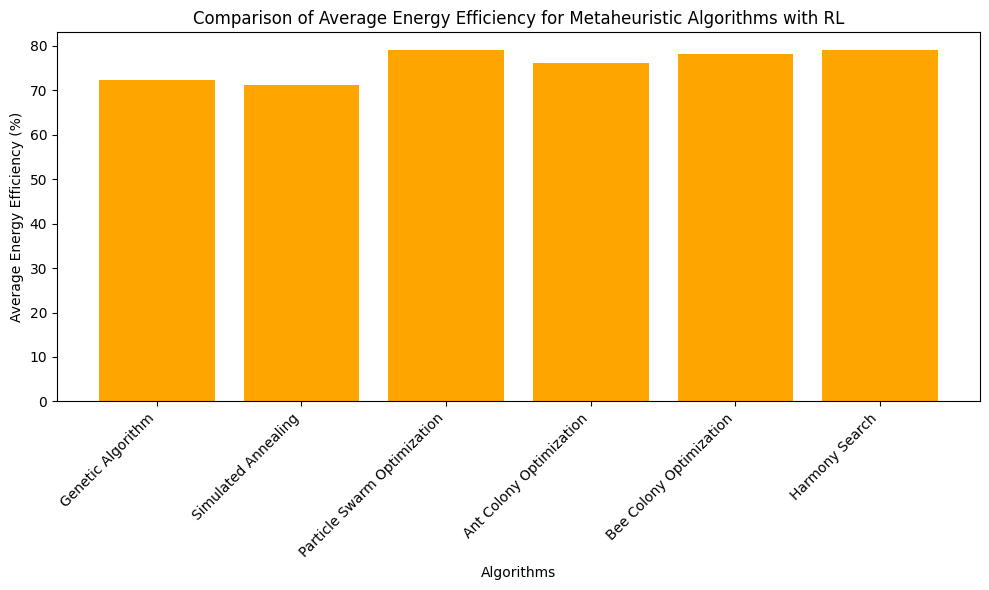

In [ ]:
import matplotlib.pyplot as plt

# Data for plotting
algorithms = ['Genetic Algorithm', 'Simulated Annealing', 'Particle Swarm Optimization',
              'Ant Colony Optimization', 'Bee Colony Optimization', 'Harmony Search']

# Metrics
avg_turnaround = [0.46, 0.47, 0.44, 0.46, 0.47, 0.48]
avg_waiting = [0.0003, 0.0004, 0.0002, 0.0003, 0.0003, 0.0004]
avg_energy_efficiency = [72.3, 71.1, 79.1, 76.2, 78.2, 79.1]

# Printing the metrics
print("Average Turnaround Time:")
for algo, value in zip(algorithms, avg_turnaround):
    print(f"{algo}: {value}")

print("\nAverage Waiting Time:")
for algo, value in zip(algorithms, avg_waiting):
    print(f"{algo}: {value}")

print("\nAverage Energy Efficiency (%):")
for algo, value in zip(algorithms, avg_energy_efficiency):
    print(f"{algo}: {value}")

# # Plotting Average Turnaround Time
# plt.figure(figsize=(10, 6))
# plt.bar(algorithms, avg_turnaround, color='blue')
# plt.xlabel('Algorithms')
# plt.ylabel('Average Turnaround Time')
# plt.title('Comparison of Average Turnaround Time for Metaheuristic Algorithms with RL')
# plt.xticks(rotation=45, ha='right')
# plt.tight_layout()
# plt.show()

# # Plotting Average Waiting Time
# plt.figure(figsize=(10, 6))
# plt.bar(algorithms, avg_waiting, color='green')
# plt.xlabel('Algorithms')
# plt.ylabel('Average Waiting Time')
# plt.title('Comparison of Average Waiting Time for Metaheuristic Algorithms with RL')
# plt.xticks(rotation=45, ha='right')
# plt.tight_layout()
# plt.show()

# Plotting Average Energy Efficiency
plt.figure(figsize=(10, 6))
plt.bar(algorithms, avg_energy_efficiency, color='orange')
plt.xlabel('Algorithms')
plt.ylabel('Average Energy Efficiency (%)')
plt.title('Comparison of Average Energy Efficiency for Metaheuristic Algorithms with RL')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


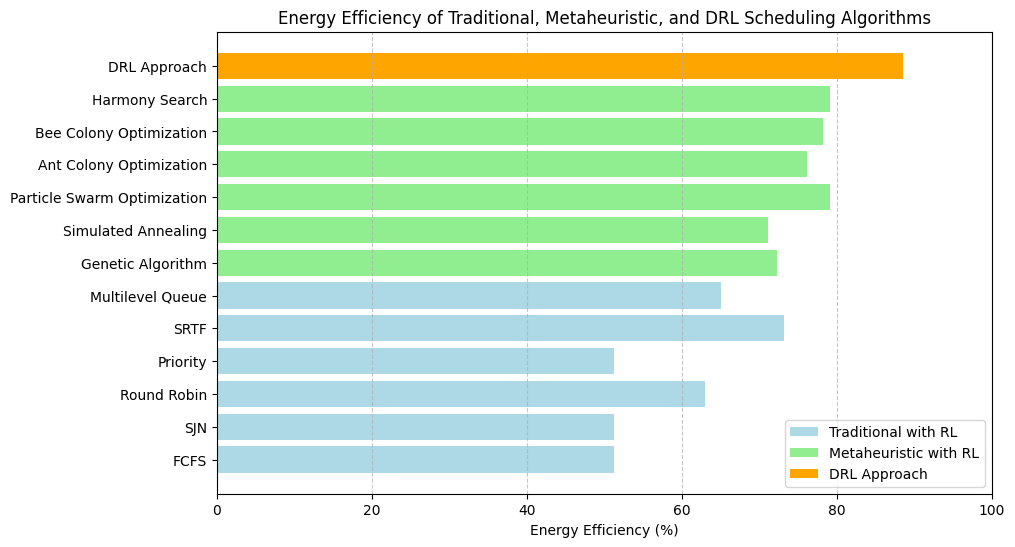

In [ ]:
import matplotlib.pyplot as plt

# Defining the categories for each algorithm
traditional_algorithms = ["FCFS", "SJN", "Round Robin", "Priority", "SRTF", "Multilevel Queue"]
metaheuristic_algorithms = [
    "Genetic Algorithm", "Simulated Annealing", "Particle Swarm Optimization",
    "Ant Colony Optimization", "Bee Colony Optimization", "Harmony Search"
]
drl_algorithm = ["DRL Approach"]

# Separating energy efficiency values based on the categories
energy_efficiency_traditional = [
    51.20, 51.20, 63.00, 51.20, 73.20, 65.10
]
energy_efficiency_metaheuristic = [
    72.3, 71.1, 79.10, 76.2, 78.2, 79.10
]
energy_efficiency_drl = [88.56]

# Create the plot
plt.figure(figsize=(10, 6))

# Plot traditional algorithms in blue
plt.barh(traditional_algorithms, energy_efficiency_traditional, color='lightblue', label='Traditional with RL')

# Plot metaheuristic algorithms in green
plt.barh(metaheuristic_algorithms, energy_efficiency_metaheuristic, color='lightgreen', label='Metaheuristic with RL')

# Plot DRL approach in orange
plt.barh(drl_algorithm, energy_efficiency_drl, color='orange', label='DRL Approach')

# Adding labels and title
plt.xlabel('Energy Efficiency (%)')
plt.title('Energy Efficiency of Traditional, Metaheuristic, and DRL Scheduling Algorithms')
plt.xlim(0, 100)
plt.grid(True, axis='x', linestyle='--', alpha=0.7)

# Adding a legend
plt.legend()

# Display the plot
plt.show()


In [ ]:
import pandas as pd
from tabulate import tabulate

# Data for the table
data = {
    "Algorithm Category": [
        "Traditional", "Traditional", "Traditional", "Traditional", "Traditional", "Traditional",
        "Metaheuristic", "Metaheuristic", "Metaheuristic", "Metaheuristic", "Metaheuristic", "Metaheuristic",
        "DRL"
    ],
    "Algorithm": [
        "FCFS", "SJN", "Round Robin", "Priority", "SRTF", "Multilevel Queue",
        "Genetic Algorithm", "Simulated Annealing", "Particle Swarm Optimization",
        "Ant Colony Optimization", "Bee Colony Optimization", "Harmony Search",
        "DRL Approach"
    ],
    "Energy Efficiency (%)": [
        51.20, 51.20, 63.00, 51.20, 73.20, 65.10,
        72.30, 71.10, 79.10, 76.20, 78.20, 79.10,
        88.56
    ]
}

# Create a DataFrame
df = pd.DataFrame(data)

# Display the table
print(tabulate(df, headers="keys", tablefmt="grid"))


+----+----------------------+-----------------------------+-------------------------+
|    | Algorithm Category   | Algorithm                   |   Energy Efficiency (%) |
+====+======================+=============================+=========================+
|  0 | Traditional          | FCFS                        |                   51.2  |
+----+----------------------+-----------------------------+-------------------------+
|  1 | Traditional          | SJN                         |                   51.2  |
+----+----------------------+-----------------------------+-------------------------+
|  2 | Traditional          | Round Robin                 |                   63    |
+----+----------------------+-----------------------------+-------------------------+
|  3 | Traditional          | Priority                    |                   51.2  |
+----+----------------------+-----------------------------+-------------------------+
|  4 | Traditional          | SRTF                    

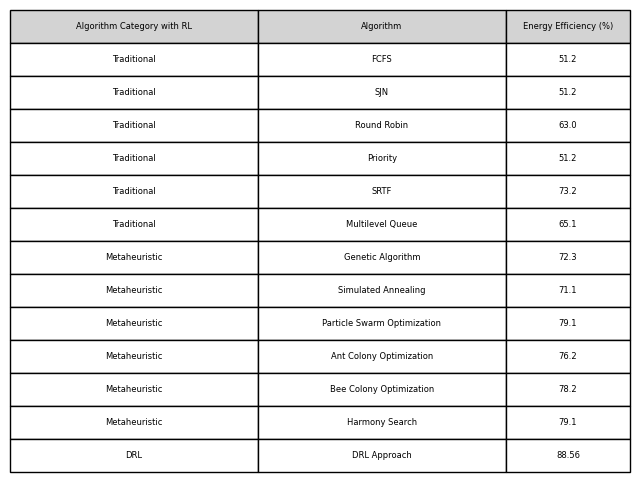

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.table import Table

# Data for the table
data = {
    "Algorithm Category with RL": [
        "Traditional", "Traditional", "Traditional", "Traditional", "Traditional", "Traditional",
        "Metaheuristic", "Metaheuristic", "Metaheuristic", "Metaheuristic", "Metaheuristic", "Metaheuristic",
        "DRL"
    ],
    "Algorithm": [
        "FCFS", "SJN", "Round Robin", "Priority", "SRTF", "Multilevel Queue",
        "Genetic Algorithm", "Simulated Annealing", "Particle Swarm Optimization",
        "Ant Colony Optimization", "Bee Colony Optimization", "Harmony Search",
        "DRL Approach"
    ],
    "Energy Efficiency (%)": [
        51.20, 51.20, 63.00, 51.20, 73.20, 65.10,
        72.30, 71.10, 79.10, 76.20, 78.20, 79.10,
        88.56
    ]
}

# Create a DataFrame
df = pd.DataFrame(data)

# Plot table as an image
fig, ax = plt.subplots(figsize=(8, 6))
ax.axis('off')  # Turn off the axes

# Create a table
table = Table(ax, bbox=[0, 0, 1, 1])

# Add cells to the table
nrows, ncols = df.shape
widths = [0.4, 0.4, 0.2]  # Column widths
heights = [0.1] * (nrows + 1)  # Row heights

# Header row
for j, col in enumerate(df.columns):
    table.add_cell(0, j, widths[j], heights[0], text=col, loc='center', facecolor='lightgray')

# Data rows
for i in range(nrows):
    for j, value in enumerate(df.iloc[i]):
        table.add_cell(i + 1, j, widths[j], heights[0], text=value, loc='center', facecolor='white')

# Add table to the plot
ax.add_table(table)

# Save the table as an image
plt.savefig("/content/Energy_Efficiency_Table.png", dpi=300, bbox_inches="tight")
plt.show()
